In [42]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [43]:

DATASET_ROOT = Path("Dataset")

categories = [
    "bottle",
    "cable",
    "capsule",
    "carpet",
    "grid",
    "hazelnut",
    "leather",
    "metal_nut",
    "pill",
    "screw",
    "tile",
    "toothbrush",
    "transistor",
    "wood",
    "zipper"
]

print("Number of categories:", len(categories))


Number of categories: 15


In [44]:

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor()
])


In [45]:

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])


In [46]:
class TrainDataset(Dataset):
    def __init__(self, image_paths, transform=None, num_samples=None):
        self.image_paths = image_paths
        self.transform = transform
        self.num_samples = num_samples

    def __len__(self):
        if self.num_samples is None:
            return len(self.image_paths)
        return self.num_samples

    def __getitem__(self, idx):
        image_path = self.image_paths[idx % len(self.image_paths)]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image


In [47]:

class TestDataset(Dataset):

    def __init__(self, root, transform=None):

        self.image_paths = []
        self.labels = []
        self.transform = transform  

        test_dir = root / "test"

        # Normal images = 0
        good_dir = test_dir / "good"

        for image_path in sorted(good_dir.glob("*.png")):
            self.image_paths.append(image_path)
            self.labels.append(0)

        # All defect folders = 1
        for defect_dir in sorted(test_dir.iterdir()):

            if not defect_dir.is_dir():
                continue

            if defect_dir.name == "good":
                continue

            for image_path in sorted(
                defect_dir.glob("*.png")
            ):
                self.image_paths.append(image_path)
                self.labels.append(1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

In [48]:
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 128, kernel_size=8, stride=1, padding=0)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 32, kernel_size=8, stride=1, padding=0),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [49]:
# Verify the model shape once
model_test = ConvAE().to(device)

dummy = torch.randn(2, 3, 256, 256).to(device)

with torch.no_grad():
    encoded = model_test.encoder(dummy)
    decoded = model_test(dummy)

print("Input:   ", dummy.shape)
print("Encoded: ", encoded.shape)
print("Decoded: ", decoded.shape)

del model_test, dummy, encoded, decoded


Input:    torch.Size([2, 3, 256, 256])
Encoded:  torch.Size([2, 128, 1, 1])
Decoded:  torch.Size([2, 3, 256, 256])


In [50]:
def calculate_validation_errors(model, loader):
    model.eval()
    errors = []

    with torch.no_grad():
        for images in loader:
            images = images.to(device)
            reconstructed = model(images)

            batch_errors = torch.mean(
                (images - reconstructed) ** 2,
                dim=(1, 2, 3)
            )

            errors.extend(batch_errors.cpu().numpy())

    return np.array(errors)


In [51]:

def calculate_test_errors(model, loader):
    model.eval()
    errors = []
    labels = []

    with torch.no_grad():
        for images, batch_labels in loader:
            images = images.to(device)
            reconstructed = model(images)

            batch_errors = torch.mean(
                (images - reconstructed) ** 2,
                dim=(1, 2, 3)
            )

            errors.extend(batch_errors.cpu().numpy())
            labels.extend(batch_labels.numpy())

    return np.array(errors), np.array(labels)


In [52]:
def run_category(
    category,
    epochs=20,
    batch_size=16,
    learning_rate=0.0002,
    num_train_samples=10000,
    threshold_percentile=99
):
    print("\n" + "=" * 70)
    print(f"PROCESSING: {category.upper()}")
    print("=" * 70)

    ROOT = DATASET_ROOT / category

    image_paths = sorted(
        (ROOT / "train" / "good").glob("*.png")
    )

    if len(image_paths) == 0:
        raise FileNotFoundError(
            f"No PNG images found in {ROOT / 'train' / 'good'}"
        )

    print(f"Total good training images: {len(image_paths)}")

    train_paths, val_paths = train_test_split(
        image_paths,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    print(f"Training images:   {len(train_paths)}")
    print(f"Validation images: {len(val_paths)}")

    train_dataset = TrainDataset(
        image_paths=train_paths,
        transform=train_transform,
        num_samples=num_train_samples
    )

    val_dataset = TrainDataset(
        image_paths=val_paths,
        transform=test_transform,
        num_samples=None
    )

    test_dataset = TestDataset(
        root=ROOT,
        transform=test_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    print(f"Test images:       {len(test_dataset)}")


    model = ConvAE().to(device)

    loss_fn = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    print("\nTraining...")

    training_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images in train_loader:
            images = images.to(device)

            optimizer.zero_grad()

            reconstructed = model(images)

            loss = loss_fn(
                reconstructed,
                images
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)
        training_losses.append(average_loss)

        print(
            f"Epoch [{epoch + 1:02d}/{epochs}] "
            f"Loss: {average_loss:.6f}"
        )

    plt.figure(figsize=(8, 5))
    plt.plot(
        range(1, epochs + 1),
        training_losses,
        marker="o"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(f"{category.upper()} - Training Loss vs Epoch")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    val_errors = calculate_validation_errors(
        model,
        val_loader
    )

    print("\nValidation:")
    print(f"Mean error: {val_errors.mean():.6f}")
    print(f"Std error:  {val_errors.std():.6f}")
    print(f"Max error:  {val_errors.max():.6f}")

    threshold = np.percentile(
        val_errors,
        threshold_percentile
    )

    print(
        f"Threshold ({threshold_percentile}th percentile): "
        f"{threshold:.6f}"
    )


    MODEL_DIR = Path("models")
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    print("Model directory:", MODEL_DIR.resolve())
    
    model_path = MODEL_DIR / f"{category}_ConvAE.pth"

    print(f"Model path: {model_path}")
    
    torch.save({
        "category": category,
        "model_state_dict": model.state_dict(),
        "threshold": threshold,
        "threshold_method": f"{threshold_percentile}th_percentile",
        "input_size": (3, 256, 256),
        "epochs": epochs,
        "learning_rate": learning_rate
    }, model_path)

    print(f"Model saved to: {model_path}")

    test_errors, test_labels = calculate_test_errors(
        model,
        test_loader
    )


    test_predictions = (
        test_errors >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        test_labels,
        test_predictions
    )

    precision = precision_score(
        test_labels,
        test_predictions,
        zero_division=0
    )

    recall = recall_score(
        test_labels,
        test_predictions,
        zero_division=0
    )

    f1 = f1_score(
        test_labels,
        test_predictions,
        zero_division=0
    )

    # Test labels are used here only to evaluate ROC-AUC.
    roc_auc = roc_auc_score(
        test_labels,
        test_errors
    )

    cm = confusion_matrix(
        test_labels,
        test_predictions
    )

    tn, fp, fn, tp = cm.ravel()

    print("\nRESULTS")
    print("-" * 50)
    print(f"Threshold : {threshold:.6f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)


    return {
        "category": category,
        "train_images": len(train_paths),
        "validation_images": len(val_paths),
        "test_images": len(test_dataset),
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "training_losses": training_losses,
        "validation_errors": val_errors,
        "test_errors": test_errors,
        "test_labels": test_labels,
        "test_predictions": test_predictions,
        "model": model
    }



PROCESSING: BOTTLE
Total good training images: 209
Training images:   167
Validation images: 42
Test images:       83

Training...


Epoch [01/20] Loss: 0.155563
Epoch [02/20] Loss: 0.090061
Epoch [03/20] Loss: 0.055064
Epoch [04/20] Loss: 0.035865
Epoch [05/20] Loss: 0.027808
Epoch [06/20] Loss: 0.023782
Epoch [07/20] Loss: 0.019457
Epoch [08/20] Loss: 0.017889
Epoch [09/20] Loss: 0.015291
Epoch [10/20] Loss: 0.013597
Epoch [11/20] Loss: 0.012601
Epoch [12/20] Loss: 0.011964
Epoch [13/20] Loss: 0.010874
Epoch [14/20] Loss: 0.010172
Epoch [15/20] Loss: 0.010127
Epoch [16/20] Loss: 0.009614
Epoch [17/20] Loss: 0.008662
Epoch [18/20] Loss: 0.008388
Epoch [19/20] Loss: 0.008382
Epoch [20/20] Loss: 0.008412


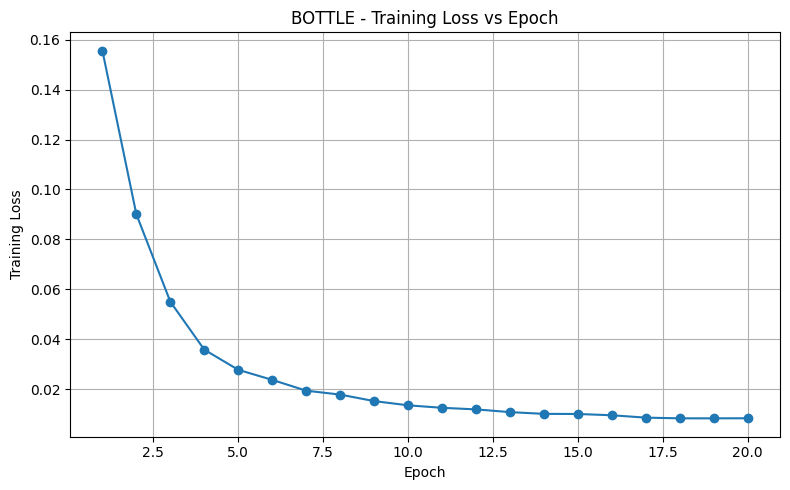


Validation:
Mean error: 0.006634
Std error:  0.000946
Max error:  0.008890
Threshold (99th percentile): 0.008733
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\bottle_ConvAE.pth
Model saved to: models\bottle_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.008733
Accuracy  : 0.5060
Precision : 1.0000
Recall    : 0.3492
F1        : 0.5176
ROC-AUC   : 0.7516

Confusion Matrix:
[[20  0]
 [41 22]]


In [53]:
bottle_result = run_category(
    "bottle",
    epochs=20,
    batch_size=16,
    learning_rate=0.0002,
    num_train_samples=2000,
    threshold_percentile=99
)



PROCESSING: BOTTLE
Total good training images: 209
Training images:   167
Validation images: 42
Test images:       83

Training...
Epoch [01/20] Loss: 0.182594
Epoch [02/20] Loss: 0.096447
Epoch [03/20] Loss: 0.057989
Epoch [04/20] Loss: 0.036860
Epoch [05/20] Loss: 0.029523
Epoch [06/20] Loss: 0.024411
Epoch [07/20] Loss: 0.020508
Epoch [08/20] Loss: 0.017717
Epoch [09/20] Loss: 0.015608
Epoch [10/20] Loss: 0.014868
Epoch [11/20] Loss: 0.013903
Epoch [12/20] Loss: 0.012994
Epoch [13/20] Loss: 0.012230
Epoch [14/20] Loss: 0.011432
Epoch [15/20] Loss: 0.010969
Epoch [16/20] Loss: 0.010877
Epoch [17/20] Loss: 0.010281
Epoch [18/20] Loss: 0.009944
Epoch [19/20] Loss: 0.009612
Epoch [20/20] Loss: 0.009767


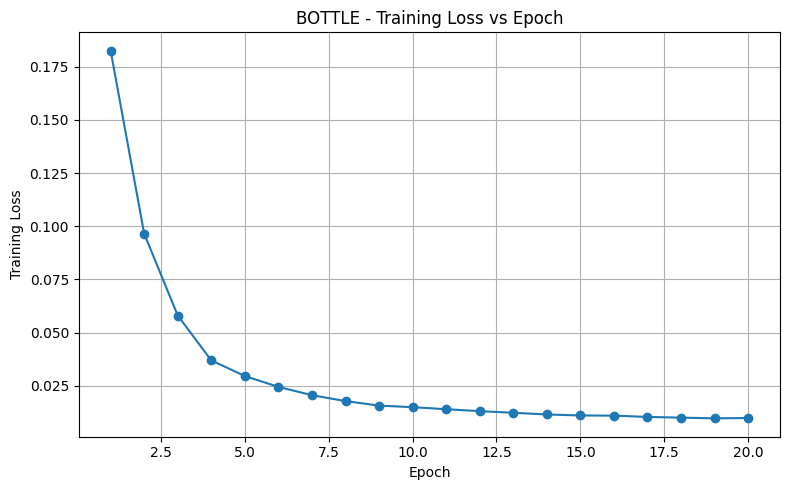


Validation:
Mean error: 0.007154
Std error:  0.001027
Max error:  0.009563
Threshold (99th percentile): 0.009518
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\bottle_ConvAE.pth
Model saved to: models\bottle_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.009518
Accuracy  : 0.4940
Precision : 1.0000
Recall    : 0.3333
F1        : 0.5000
ROC-AUC   : 0.7325

Confusion Matrix:
[[20  0]
 [42 21]]

PROCESSING: CABLE
Total good training images: 224
Training images:   179
Validation images: 45
Test images:       150

Training...
Epoch [01/20] Loss: 0.075003
Epoch [02/20] Loss: 0.043982
Epoch [03/20] Loss: 0.030702
Epoch [04/20] Loss: 0.024317
Epoch [05/20] Loss: 0.020699
Epoch [06/20] Loss: 0.019070
Epoch [07/20] Loss: 0.017974
Epoch [08/20] Loss: 0.017208
Epoch [09/20] Loss: 0.016612
Epoch [10/20] Loss: 0.015924
Epoch [11/20] Loss: 0.015538
Epoch [12/20] Loss: 0.015077
E

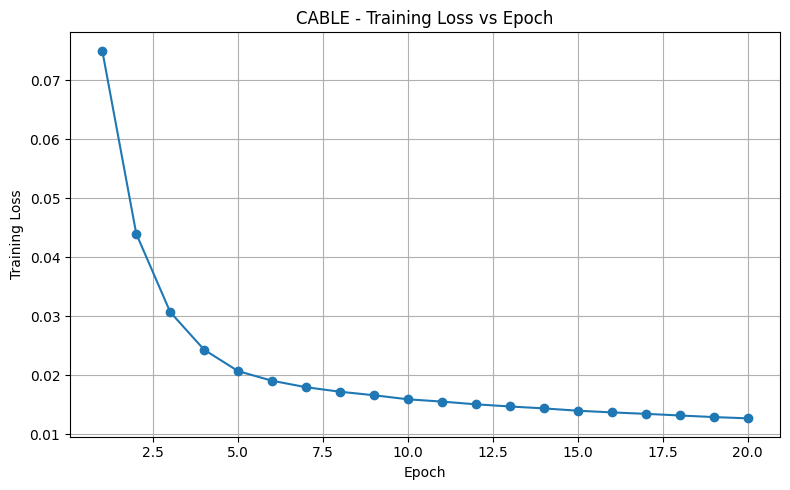


Validation:
Mean error: 0.013208
Std error:  0.001867
Max error:  0.019705
Threshold (99th percentile): 0.018941
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\cable_ConvAE.pth
Model saved to: models\cable_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.018941
Accuracy  : 0.3867
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
ROC-AUC   : 0.6555

Confusion Matrix:
[[58  0]
 [92  0]]

PROCESSING: CAPSULE
Total good training images: 219
Training images:   175
Validation images: 44
Test images:       132

Training...
Epoch [01/20] Loss: 0.190640
Epoch [02/20] Loss: 0.075216
Epoch [03/20] Loss: 0.063317
Epoch [04/20] Loss: 0.034399
Epoch [05/20] Loss: 0.023693
Epoch [06/20] Loss: 0.017715
Epoch [07/20] Loss: 0.013784
Epoch [08/20] Loss: 0.011749
Epoch [09/20] Loss: 0.010253
Epoch [10/20] Loss: 0.009328
Epoch [11/20] Loss: 0.008325
Epoch [12/20] Loss: 0.007633
E

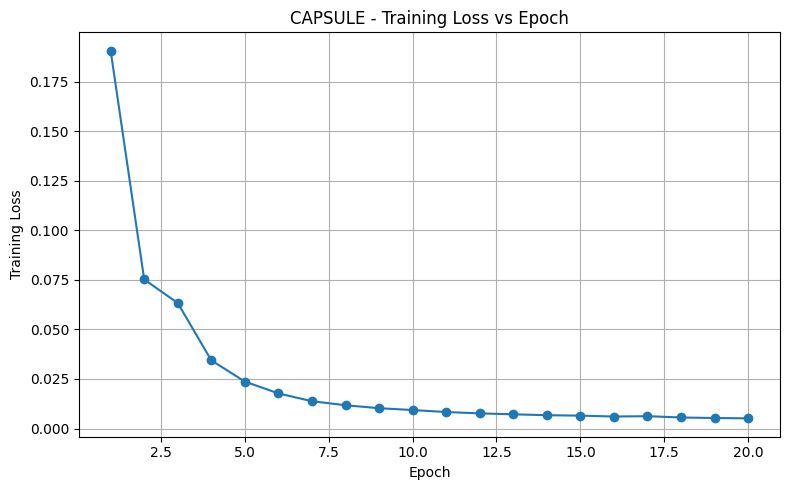


Validation:
Mean error: 0.002488
Std error:  0.000284
Max error:  0.003465
Threshold (99th percentile): 0.003426
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\capsule_ConvAE.pth
Model saved to: models\capsule_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.003426
Accuracy  : 0.2727
Precision : 0.9333
Recall    : 0.1284
F1        : 0.2258
ROC-AUC   : 0.5592

Confusion Matrix:
[[22  1]
 [95 14]]

PROCESSING: CARPET
Total good training images: 280
Training images:   224
Validation images: 56
Test images:       117

Training...
Epoch [01/20] Loss: 0.049011
Epoch [02/20] Loss: 0.021369
Epoch [03/20] Loss: 0.021302
Epoch [04/20] Loss: 0.021504
Epoch [05/20] Loss: 0.021210
Epoch [06/20] Loss: 0.019953
Epoch [07/20] Loss: 0.015408
Epoch [08/20] Loss: 0.013677
Epoch [09/20] Loss: 0.013049
Epoch [10/20] Loss: 0.012834
Epoch [11/20] Loss: 0.012604
Epoch [12/20] Loss: 0.01249

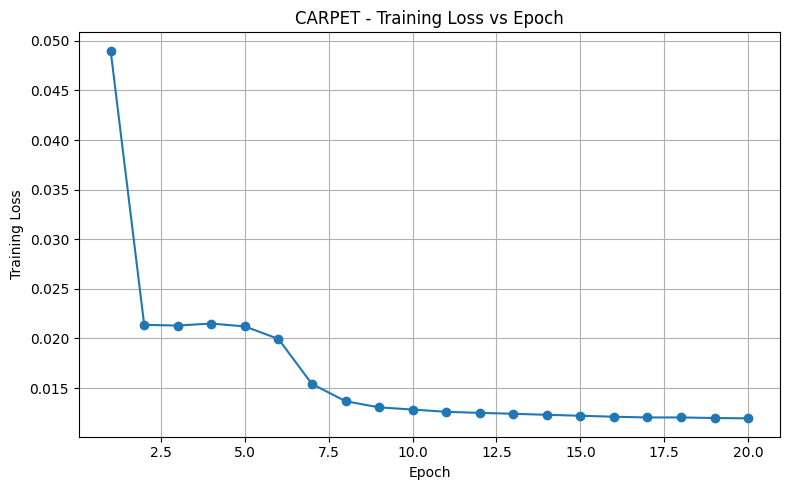


Validation:
Mean error: 0.012873
Std error:  0.001043
Max error:  0.016552
Threshold (99th percentile): 0.015955
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\carpet_ConvAE.pth
Model saved to: models\carpet_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.015955
Accuracy  : 0.2479
Precision : 1.0000
Recall    : 0.0112
F1        : 0.0222
ROC-AUC   : 0.4121

Confusion Matrix:
[[28  0]
 [88  1]]

PROCESSING: GRID
Total good training images: 264
Training images:   211
Validation images: 53
Test images:       78

Training...
Epoch [01/20] Loss: 0.084806
Epoch [02/20] Loss: 0.038185
Epoch [03/20] Loss: 0.037365
Epoch [04/20] Loss: 0.032468
Epoch [05/20] Loss: 0.027557
Epoch [06/20] Loss: 0.025247
Epoch [07/20] Loss: 0.024106
Epoch [08/20] Loss: 0.023566
Epoch [09/20] Loss: 0.023208
Epoch [10/20] Loss: 0.022774
Epoch [11/20] Loss: 0.022535
Epoch [12/20] Loss: 0.022316
Epo

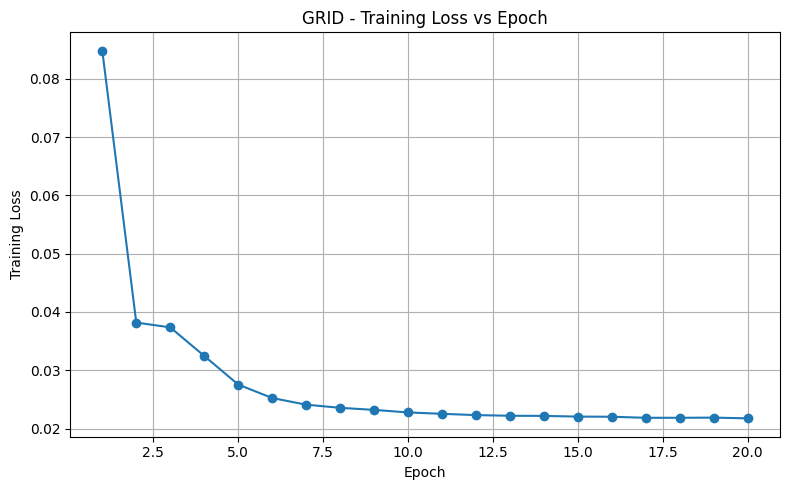


Validation:
Mean error: 0.024549
Std error:  0.010440
Max error:  0.049378
Threshold (99th percentile): 0.048244
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\grid_ConvAE.pth
Model saved to: models\grid_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.048244
Accuracy  : 0.2692
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
ROC-AUC   : 0.7544

Confusion Matrix:
[[21  0]
 [57  0]]

PROCESSING: HAZELNUT
Total good training images: 391
Training images:   312
Validation images: 79
Test images:       110

Training...
Epoch [01/20] Loss: 0.018409
Epoch [02/20] Loss: 0.006561
Epoch [03/20] Loss: 0.003797
Epoch [04/20] Loss: 0.003181
Epoch [05/20] Loss: 0.002620
Epoch [06/20] Loss: 0.002204
Epoch [07/20] Loss: 0.001992
Epoch [08/20] Loss: 0.001813
Epoch [09/20] Loss: 0.001698
Epoch [10/20] Loss: 0.001630
Epoch [11/20] Loss: 0.001516
Epoch [12/20] Loss: 0.001499
Ep

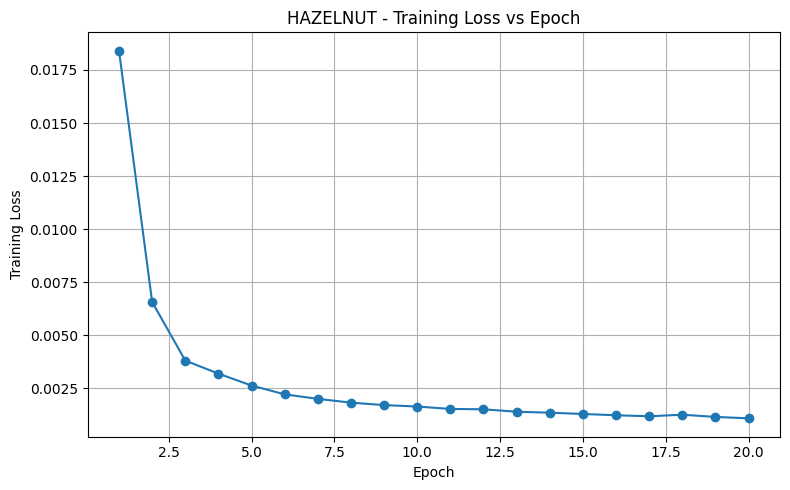


Validation:
Mean error: 0.000957
Std error:  0.000241
Max error:  0.001709
Threshold (99th percentile): 0.001689
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\hazelnut_ConvAE.pth
Model saved to: models\hazelnut_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.001689
Accuracy  : 0.5909
Precision : 1.0000
Recall    : 0.3571
F1        : 0.5263
ROC-AUC   : 0.7043

Confusion Matrix:
[[40  0]
 [45 25]]

PROCESSING: LEATHER
Total good training images: 245
Training images:   196
Validation images: 49
Test images:       124

Training...
Epoch [01/20] Loss: 0.022240
Epoch [02/20] Loss: 0.008394
Epoch [03/20] Loss: 0.008299
Epoch [04/20] Loss: 0.008078
Epoch [05/20] Loss: 0.004700
Epoch [06/20] Loss: 0.002925
Epoch [07/20] Loss: 0.002166
Epoch [08/20] Loss: 0.001767
Epoch [09/20] Loss: 0.001644
Epoch [10/20] Loss: 0.001432
Epoch [11/20] Loss: 0.001350
Epoch [12/20] Loss: 0.00

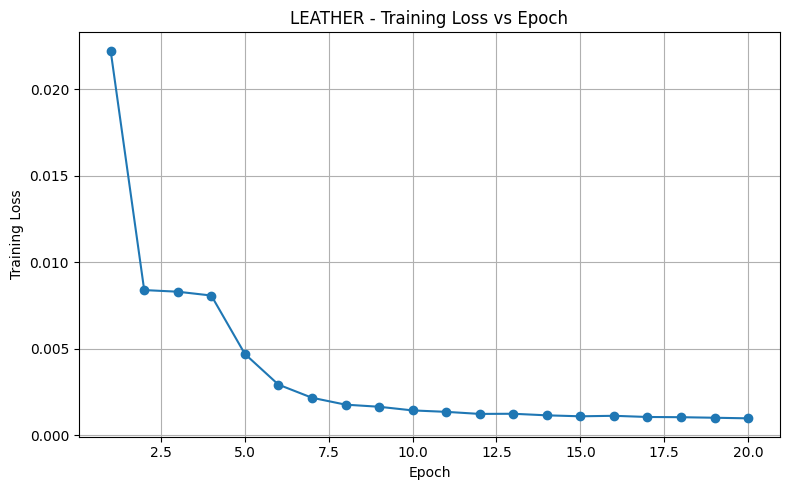


Validation:
Mean error: 0.000647
Std error:  0.000120
Max error:  0.000942
Threshold (99th percentile): 0.000941
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\leather_ConvAE.pth
Model saved to: models\leather_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.000941
Accuracy  : 0.6532
Precision : 0.7168
Recall    : 0.8804
F1        : 0.7902
ROC-AUC   : 0.6250

Confusion Matrix:
[[ 0 32]
 [11 81]]

PROCESSING: METAL_NUT
Total good training images: 220
Training images:   176
Validation images: 44
Test images:       115

Training...
Epoch [01/20] Loss: 0.034879
Epoch [02/20] Loss: 0.019833
Epoch [03/20] Loss: 0.015227
Epoch [04/20] Loss: 0.012224
Epoch [05/20] Loss: 0.009925
Epoch [06/20] Loss: 0.008328
Epoch [07/20] Loss: 0.007613
Epoch [08/20] Loss: 0.006982
Epoch [09/20] Loss: 0.006688
Epoch [10/20] Loss: 0.006408
Epoch [11/20] Loss: 0.006233
Epoch [12/20] Loss: 0.00

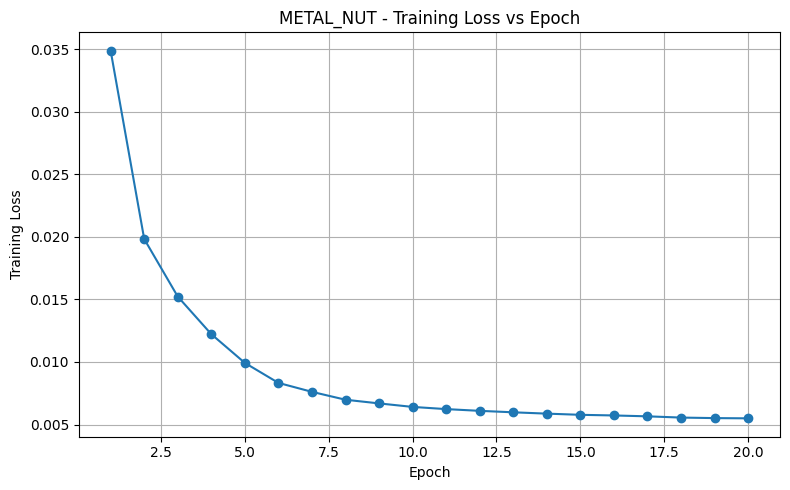


Validation:
Mean error: 0.005379
Std error:  0.001373
Max error:  0.009490
Threshold (99th percentile): 0.009415
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\metal_nut_ConvAE.pth
Model saved to: models\metal_nut_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.009415
Accuracy  : 0.1913
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
ROC-AUC   : 0.4702

Confusion Matrix:
[[22  0]
 [93  0]]

PROCESSING: PILL
Total good training images: 267
Training images:   213
Validation images: 54
Test images:       167

Training...
Epoch [01/20] Loss: 0.077629
Epoch [02/20] Loss: 0.028656
Epoch [03/20] Loss: 0.026278
Epoch [04/20] Loss: 0.009850
Epoch [05/20] Loss: 0.006269
Epoch [06/20] Loss: 0.004600
Epoch [07/20] Loss: 0.003730
Epoch [08/20] Loss: 0.003141
Epoch [09/20] Loss: 0.002907
Epoch [10/20] Loss: 0.002663
Epoch [11/20] Loss: 0.002398
Epoch [12/20] Loss: 0.002

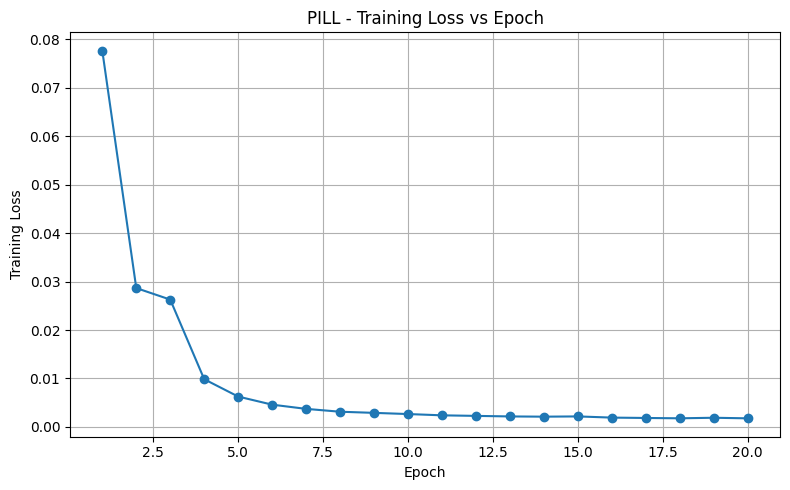


Validation:
Mean error: 0.001425
Std error:  0.000180
Max error:  0.001940
Threshold (99th percentile): 0.001907
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\pill_ConvAE.pth
Model saved to: models\pill_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.001907
Accuracy  : 0.2635
Precision : 1.0000
Recall    : 0.1277
F1        : 0.2264
ROC-AUC   : 0.6923

Confusion Matrix:
[[ 26   0]
 [123  18]]

PROCESSING: SCREW
Total good training images: 320
Training images:   256
Validation images: 64
Test images:       160

Training...
Epoch [01/20] Loss: 0.194176
Epoch [02/20] Loss: 0.062226
Epoch [03/20] Loss: 0.063089
Epoch [04/20] Loss: 0.056830
Epoch [05/20] Loss: 0.036766
Epoch [06/20] Loss: 0.026041
Epoch [07/20] Loss: 0.017036
Epoch [08/20] Loss: 0.013735
Epoch [09/20] Loss: 0.011808
Epoch [10/20] Loss: 0.010387
Epoch [11/20] Loss: 0.009615
Epoch [12/20] Loss: 0.008562
E

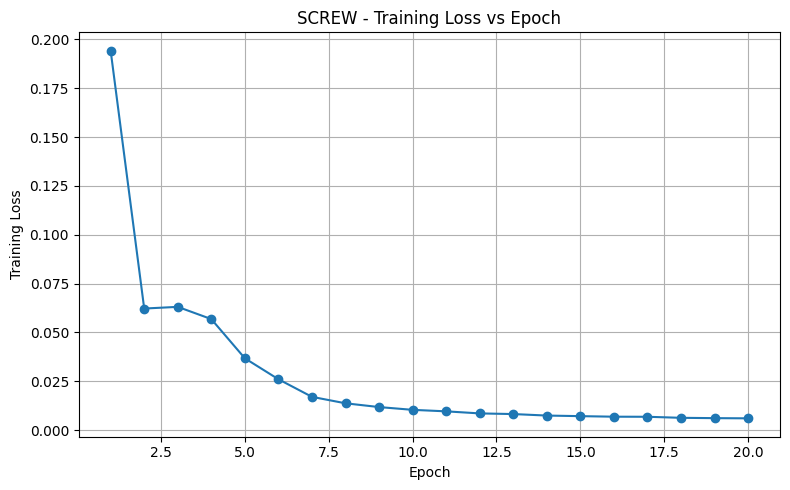


Validation:
Mean error: 0.002769
Std error:  0.000268
Max error:  0.003506
Threshold (99th percentile): 0.003414
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\screw_ConvAE.pth
Model saved to: models\screw_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.003414
Accuracy  : 0.2562
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
ROC-AUC   : 0.9932

Confusion Matrix:
[[ 41   0]
 [119   0]]

PROCESSING: TILE
Total good training images: 230
Training images:   184
Validation images: 46
Test images:       117

Training...
Epoch [01/20] Loss: 0.070255
Epoch [02/20] Loss: 0.030085
Epoch [03/20] Loss: 0.030016
Epoch [04/20] Loss: 0.028328
Epoch [05/20] Loss: 0.021676
Epoch [06/20] Loss: 0.018752
Epoch [07/20] Loss: 0.016906
Epoch [08/20] Loss: 0.015899
Epoch [09/20] Loss: 0.015230
Epoch [10/20] Loss: 0.014809
Epoch [11/20] Loss: 0.014505
Epoch [12/20] Loss: 0.014179


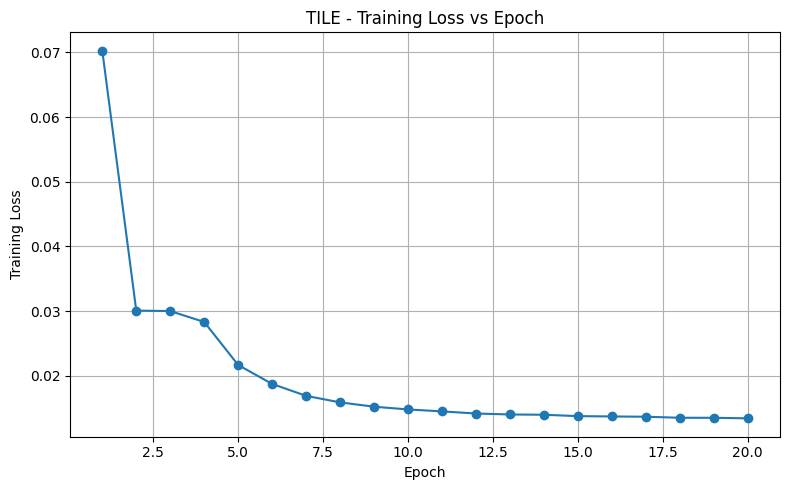


Validation:
Mean error: 0.014294
Std error:  0.002227
Max error:  0.019835
Threshold (99th percentile): 0.019528
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\tile_ConvAE.pth
Model saved to: models\tile_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.019528
Accuracy  : 0.2821
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
ROC-AUC   : 0.6053

Confusion Matrix:
[[33  0]
 [84  0]]

PROCESSING: TOOTHBRUSH
Total good training images: 60
Training images:   48
Validation images: 12
Test images:       42

Training...
Epoch [01/20] Loss: 0.047585
Epoch [02/20] Loss: 0.024342
Epoch [03/20] Loss: 0.018832
Epoch [04/20] Loss: 0.012774
Epoch [05/20] Loss: 0.010004
Epoch [06/20] Loss: 0.008519
Epoch [07/20] Loss: 0.007377
Epoch [08/20] Loss: 0.006793
Epoch [09/20] Loss: 0.006268
Epoch [10/20] Loss: 0.006032
Epoch [11/20] Loss: 0.005710
Epoch [12/20] Loss: 0.005572
Epo

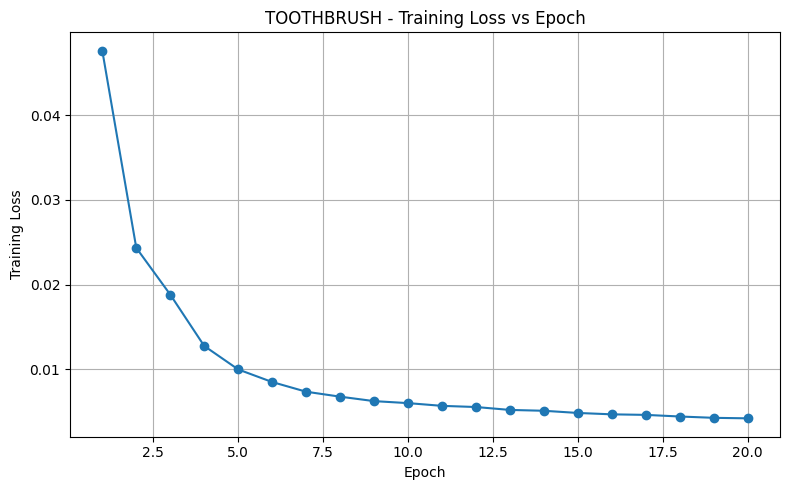


Validation:
Mean error: 0.003685
Std error:  0.000572
Max error:  0.004627
Threshold (99th percentile): 0.004610
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\toothbrush_ConvAE.pth
Model saved to: models\toothbrush_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.004610
Accuracy  : 0.3810
Precision : 0.8333
Recall    : 0.1667
F1        : 0.2778
ROC-AUC   : 0.6528

Confusion Matrix:
[[11  1]
 [25  5]]

PROCESSING: TRANSISTOR
Total good training images: 213
Training images:   170
Validation images: 43
Test images:       100

Training...
Epoch [01/20] Loss: 0.064311
Epoch [02/20] Loss: 0.030090
Epoch [03/20] Loss: 0.029801
Epoch [04/20] Loss: 0.029474
Epoch [05/20] Loss: 0.025872
Epoch [06/20] Loss: 0.019023
Epoch [07/20] Loss: 0.016254
Epoch [08/20] Loss: 0.015028
Epoch [09/20] Loss: 0.014453
Epoch [10/20] Loss: 0.013876
Epoch [11/20] Loss: 0.013424
Epoch [12/20] Los

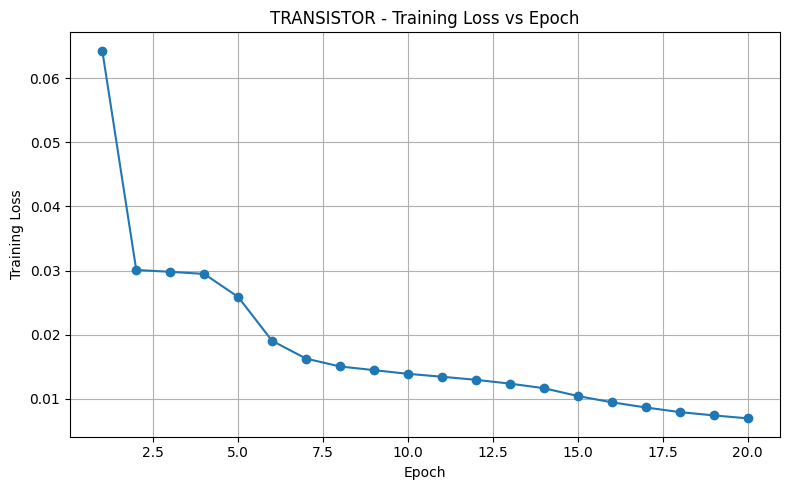


Validation:
Mean error: 0.006100
Std error:  0.000753
Max error:  0.008035
Threshold (99th percentile): 0.007867
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\transistor_ConvAE.pth
Model saved to: models\transistor_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.007867
Accuracy  : 0.6900
Precision : 0.8462
Recall    : 0.2750
F1        : 0.4151
ROC-AUC   : 0.6392

Confusion Matrix:
[[58  2]
 [29 11]]

PROCESSING: WOOD
Total good training images: 247
Training images:   197
Validation images: 50
Test images:       79

Training...
Epoch [01/20] Loss: 0.059750
Epoch [02/20] Loss: 0.024032
Epoch [03/20] Loss: 0.019487
Epoch [04/20] Loss: 0.011599
Epoch [05/20] Loss: 0.008635
Epoch [06/20] Loss: 0.007004
Epoch [07/20] Loss: 0.006045
Epoch [08/20] Loss: 0.005452
Epoch [09/20] Loss: 0.004880
Epoch [10/20] Loss: 0.004520
Epoch [11/20] Loss: 0.004355
Epoch [12/20] Loss: 0.00

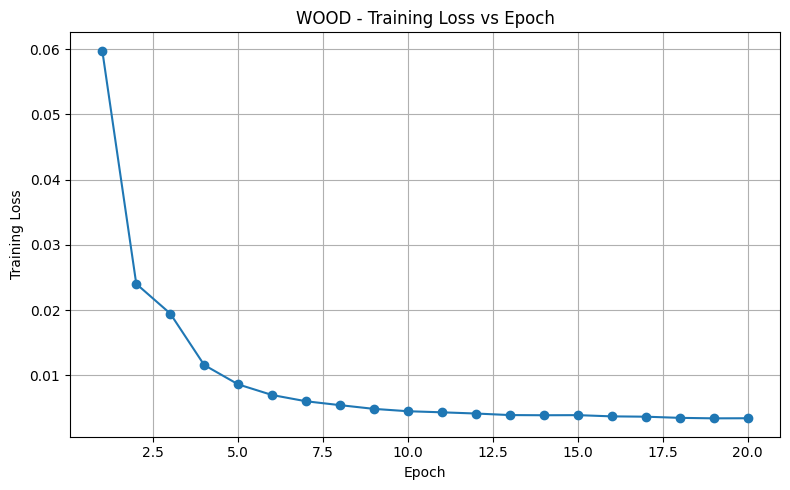


Validation:
Mean error: 0.002509
Std error:  0.000769
Max error:  0.004226
Threshold (99th percentile): 0.004157
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\wood_ConvAE.pth
Model saved to: models\wood_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.004157
Accuracy  : 0.4430
Precision : 1.0000
Recall    : 0.2667
F1        : 0.4211
ROC-AUC   : 0.9202

Confusion Matrix:
[[19  0]
 [44 16]]

PROCESSING: ZIPPER
Total good training images: 240
Training images:   192
Validation images: 48
Test images:       151

Training...
Epoch [01/20] Loss: 0.098181
Epoch [02/20] Loss: 0.064359
Epoch [03/20] Loss: 0.037178
Epoch [04/20] Loss: 0.020872
Epoch [05/20] Loss: 0.016444
Epoch [06/20] Loss: 0.014310
Epoch [07/20] Loss: 0.013121
Epoch [08/20] Loss: 0.011631
Epoch [09/20] Loss: 0.010399
Epoch [10/20] Loss: 0.009713
Epoch [11/20] Loss: 0.008875
Epoch [12/20] Loss: 0.008539
Epoc

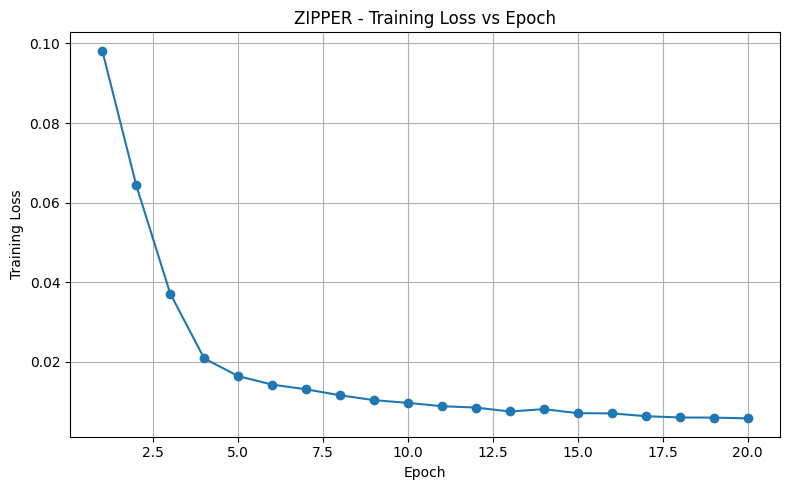


Validation:
Mean error: 0.003906
Std error:  0.000677
Max error:  0.007103
Threshold (99th percentile): 0.006232
Model directory: C:\Users\jaysu\OneDrive\Desktop\PROJECTS\AP1\Anomoly-detector-for-manufacturing-products\models
Model path: models\zipper_ConvAE.pth
Model saved to: models\zipper_ConvAE.pth

RESULTS
--------------------------------------------------
Threshold : 0.006232
Accuracy  : 0.2053
Precision : 0.4000
Recall    : 0.0168
F1        : 0.0323
ROC-AUC   : 0.5578

Confusion Matrix:
[[ 29   3]
 [117   2]]


In [54]:
all_results = []

for category in categories:
    try:
        result = run_category(
            category,
            epochs=20,
            batch_size=16,
            learning_rate=0.0002,
            num_train_samples=2000,
            threshold_percentile=99
        )

        all_results.append(result)

    except Exception as e:
        print("\n" + "=" * 70)
        print(f"ERROR IN CATEGORY: {category}")
        print("=" * 70)
        print(e)


In [66]:
# Create a clean results table
results_df = pd.DataFrame([
    {
        "Category": r["category"],
        "Train Images": r["train_images"],
        "Validation Images": r["validation_images"],
        "Test Images": r["test_images"],
        "Threshold": r["threshold"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "ROC-AUC": r["roc_auc"],
        "TN": r["TN"],
        "FP": r["FP"],
        "FN": r["FN"],
        "TP": r["TP"]
    }
    for r in all_results
])

results_df


,Category,Train Images,Validation Images,Test Images,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,bottle,167,42,83,0.009518,0.493976,1.000000,0.333333,0.500000,0.732540,20,0,42,21
1,cable,179,45,150,0.018941,0.386667,0.000000,0.000000,0.000000,0.655547,58,0,92,0
2,capsule,175,44,132,0.003426,0.272727,0.933333,0.128440,0.225806,0.559234,22,1,95,14
3,carpet,224,56,117,0.015955,0.247863,1.000000,0.011236,0.022222,0.412119,28,0,88,1
4,grid,211,53,78,0.048244,0.269231,0.000000,0.000000,0.000000,0.754386,21,0,57,0
5,hazelnut,312,79,110,0.001689,0.590909,1.000000,0.357143,0.526316,0.704286,40,0,45,25
6,leather,196,49,124,0.000941,0.653226,0.716814,0.880435,0.790244,0.625000,0,32,11,81
7,metal_nut,176,44,115,0.009415,0.191304,0.000000,0.000000,0.000000,0.470186,22,0,93,0
8,pill,213,54,167,0.001907,0.263473,1.000000,0.127660,0.226415,0.692308,26,0,123,18
9,screw,256,64,160,0.003414,0.256250,0.000000,0.000000,0.000000,0.993236,41,0,119,0


In [67]:
# Save results

results_df.to_csv(
    "mvtec_all_categories_results.csv",
    index=False
)

print("Saved: mvtec_all_categories_results.csv")


Saved: mvtec_all_categories_results.csv


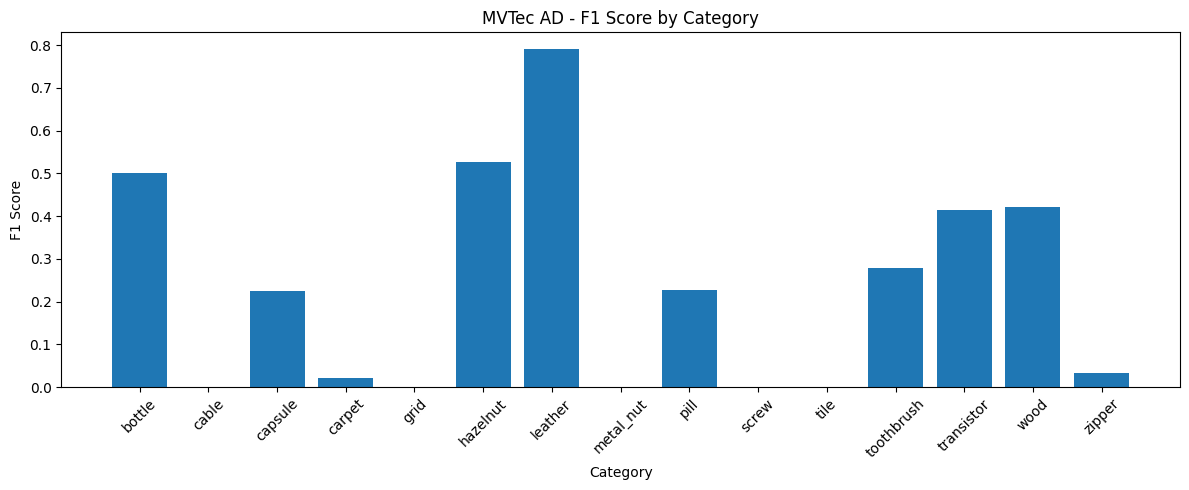

In [68]:
# Optional: plot F1 score for each category

plt.figure(figsize=(12, 5))

plt.bar(
    results_df["Category"],
    results_df["F1"]
)

plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.title("MVTec AD - F1 Score by Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


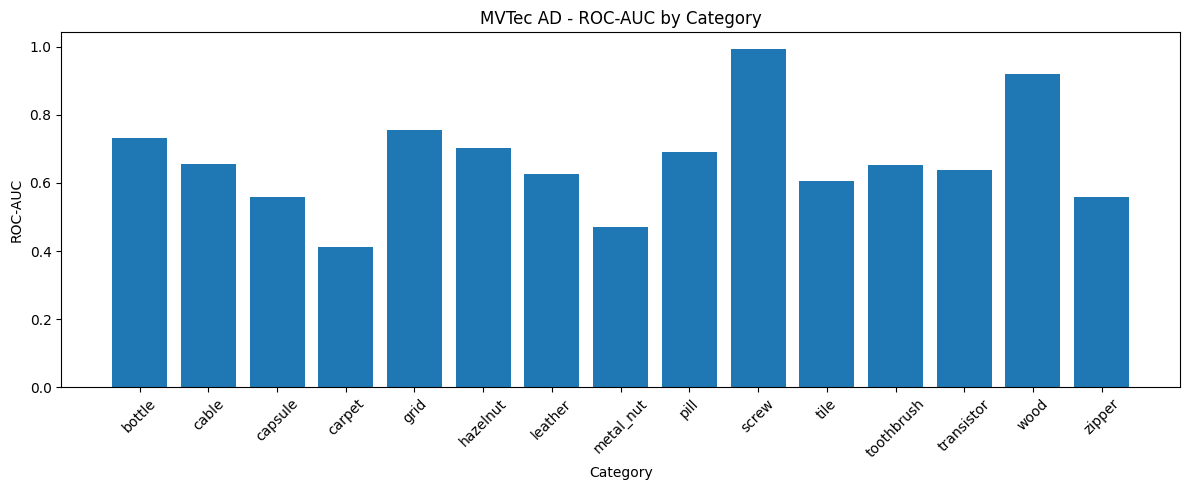

In [69]:
# Optional: plot ROC-AUC for each category

plt.figure(figsize=(12, 5))

plt.bar(
    results_df["Category"],
    results_df["ROC-AUC"]
)

plt.xlabel("Category")
plt.ylabel("ROC-AUC")
plt.title("MVTec AD - ROC-AUC by Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
